# Teste Técnico - Cientista de Dados Junior
**Candidato**: Pedro Vicente Moda

---

## 1. Análise Exploratória de Dados (EDA)

### 1.1 Carregando dataset e exibindo primeiras linhas

In [75]:
# Importação de bibliotecas.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Configurações de visualização
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

# Carregamento dos dados
df = pd.read_csv("dados_clientes_teste_cientista.csv", delimiter=",")

print(" ===== Número de linhas e colunas do dataset ===== ")
print()

print(f"Shape do dataset: {df.shape}")
print()



print("===== Primeiras 5 linhas do dataset ===== ")
print()

df.head()


 ===== Número de linhas e colunas do dataset ===== 

Shape do dataset: (1000, 7)

===== Primeiras 5 linhas do dataset ===== 



,id_cliente,idade,sexo,renda_mensal,tempo_como_cliente,uso_app_diario,cancelou_servico
0,1,39,Feminino,4452.017673,10,80.098661,1
1,2,33,Masculino,5277.020459,2,45.368033,0
2,3,41,Feminino,2979.310566,9,49.505282,0
3,4,50,Masculino,3542.578942,3,58.854455,0
4,5,32,Feminino,6800.620862,2,19.613390,0


### 1.2 Verificando valores ausentes e duplicados no dataset.

In [76]:
# Verificando Ausentes

print(" ===== Valores ausentes ===== ")
print()
print(df.isnull().sum())
print()

# Verificando duplicados

print(" ===== Valores duplicados ===== ")
print()
print(df.duplicated().sum())
print()


 ===== Valores ausentes ===== 

id_cliente            0
idade                 0
sexo                  0
renda_mensal          0
tempo_como_cliente    0
uso_app_diario        0
cancelou_servico      0
dtype: int64

 ===== Valores duplicados ===== 

0



>**Notas:** Observei que o dataset não possui valores ausentes e nem duplicados. Portanto, nenhuma imputação de dados será necessária. Em casos de imputação, comumente utilizamos a média dos valores para distribuições simétricas, como também, em algumas vezes, a mediana quando há outliers e também a moda quando categórias.

#### 1.2.1 Verificando tipos de dados e análise descritiva dos dados.

In [77]:
# Verificando tipo de dados

print(" ===== Tipos de dados ===== ")
print()
print(df.dtypes)
print()

# Estatísticas descritivas
print(" ===== Estatísticas descritivas ===== ")
print()
print(df.describe())
print()

 ===== Tipos de dados ===== 

id_cliente              int64
idade                   int64
sexo                   object
renda_mensal          float64
tempo_como_cliente      int64
uso_app_diario        float64
cancelou_servico        int64
dtype: object

 ===== Estatísticas descritivas ===== 

        id_cliente        idade  renda_mensal  tempo_como_cliente  \
count  1000.000000  1000.000000   1000.000000         1000.000000   
mean    500.500000    34.674000   5046.285355            5.540000   
std     288.819436     9.797741   1471.235533            2.895304   
min       1.000000     2.000000   1000.000000            1.000000   
25%     250.750000    28.000000   4068.052941            3.000000   
50%     500.500000    35.000000   5025.153363            6.000000   
75%     750.250000    41.000000   6026.384910            8.000000   
max    1000.000000    73.000000   9789.661352           10.000000   

       uso_app_diario  cancelou_servico  
count     1000.000000       1000.000000  

>**Notas:** Além disso, a tipagem das colunas está correta, não sendo necessário nenhum tipo de transformação para tipagem. Olhando para as estatísticas descritivas, me veio uma hipótese que quanto maior o salário, maior tempo como cliente (Vou descobrir a seguir). E também, observei que a idade mínima neste dataset é 2 anos, indicando um possível erro no preenchimento da informação.

In [78]:
# Verificando correlação entre idade e tempo como cliente.

correlacao = df["renda_mensal"].corr(df["tempo_como_cliente"])
print(f"Correlação entre renda mensal e tempo como cliente: {correlacao:.4f}")
print()


Correlação entre renda mensal e tempo como cliente: 0.0161



>**Notas:** Minha hipótese inicial estava incorreta, uma correlação de 0.02 indica que não há relação **linear** evidente entre as variáveis.

In [79]:
# Criando grupo de idade para identificar a distribuição de clientes por faixa etária.
bins = [0, 6, 11, 16, 26, 31, 36, 41, 46, 51, 56, 61, 100]
labels = ["0-5", "6-10", "11-17", "18-25", "26-30", "31-35", "36-40", "41-45", "46-50", "51-55", "56-60", "61+"]
df["faixa_etaria"] = pd.cut(df["idade"], bins=bins, labels=labels, right=False)
print(" ===== Distribuição de clientes por faixa etária ===== ")
print()
print(df["faixa_etaria"].value_counts().sort_index(ascending=True))
print()

 ===== Distribuição de clientes por faixa etária ===== 

faixa_etaria
0-5        1
6-10       5
11-17     16
18-25    150
26-30    179
31-35    186
36-40    189
41-45    143
46-50     75
51-55     36
56-60     16
61+        4
Name: count, dtype: int64



In [80]:
df_filtrado_idade = df[(df["idade"].between(0,17))]
df_filtrado_idade

,id_cliente,idade,sexo,renda_mensal,tempo_como_cliente,uso_app_diario,cancelou_servico,faixa_etaria
13,14,15,Feminino,7252.000478,4,40.029428,1,11-17
14,15,17,Masculino,4515.980242,9,69.010633,0,18-25
37,38,15,Feminino,6223.605819,9,66.412211,0,11-17
49,50,17,Masculino,3054.752078,1,50.029472,1,18-25
74,75,8,Masculino,3206.175407,10,61.935416,0,6-10
79,80,15,Masculino,5022.032292,9,54.400884,0,11-17
110,111,15,Masculino,4744.723066,7,15.664296,0,11-17
221,222,16,Masculino,9789.661352,6,40.766660,0,18-25
236,237,14,Feminino,5727.099226,6,49.332500,0,11-17
262,263,2,Masculino,5252.691464,7,23.156727,0,0-5


>**Notas:** Seria importante entender a fundo o preenchimento da idade, se é algum cálculo incorreto, inserção incorreta da informação, e também, verificar junto a área de negócio, pois isso pode indicar inconsistência ou regra de negócio específica. Dependendo do caso, as variáveis para esses casos de menores de idade podem distorcer o resultado do modelo estatístico, levando a uma tomada de decisão incorreta.

### 1.3 Mediana da renda mensal por sexo.

In [81]:
mediana_renda = df.groupby('sexo')['renda_mensal'].median().round(2)
print(" ===== Mediana da renda mensal por sexo ===== ")
print()
print(mediana_renda)

 ===== Mediana da renda mensal por sexo ===== 

sexo
Feminino     5036.33
Masculino    4998.94
Name: renda_mensal, dtype: float64


>**Notas:** A mediana da renda mensal entre os sexos é muito semelhante, com uma pequena diferença a favor do sexo feminimo. Essa leve diferença, a olhos nus, indica que não há uma diferença significativa de renda entre os grupos.

### 1.4 Histograma da idade dos clientes.

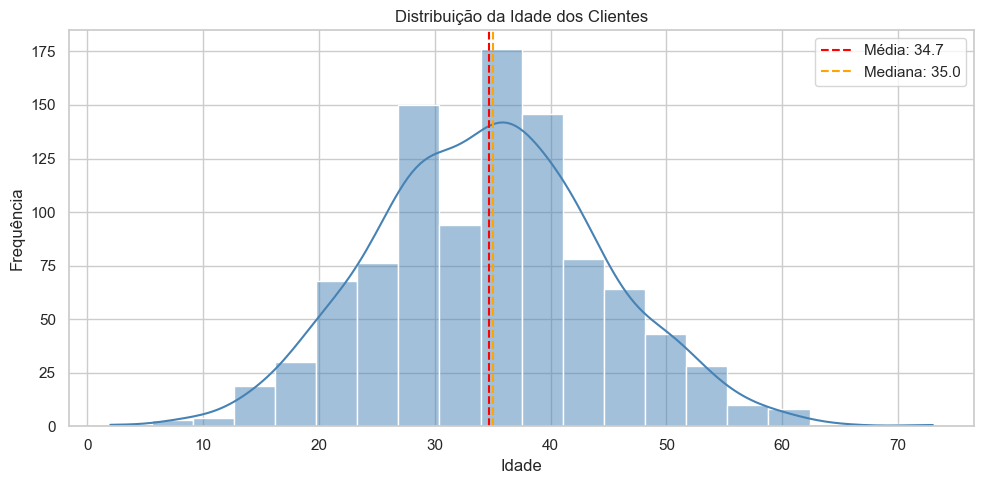

In [82]:
fig, ax = plt.subplots()
sns.histplot(df["idade"], bins=20, kde=True, ax=ax, color="steelblue")
ax.axvline(df["idade"].mean(), color="red", linestyle="--", label=f"Média: {df['idade'].mean():.1f}")
ax.axvline(df["idade"].median(), color="orange", linestyle="--", label=f"Mediana: {df['idade'].median():.1f}")
ax.set_title("Distribuição da Idade dos Clientes")
ax.set_xlabel("Idade")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.show()

>**Notas:** A distribuição da idade dos clientes é aproximadamente simétrica, com média de 34,7 e mediana de 35,0 anos, valores muito próximos, indicando ausência de assimetria relevante. A maior concentração de clientes está entre 30 e 40 anos.

### 1.5 Relação entre tempo como cliente (e outras variáveis) e cancelamento.

C:\Users\pedro\AppData\Local\Temp\ipykernel_27936\3865104026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


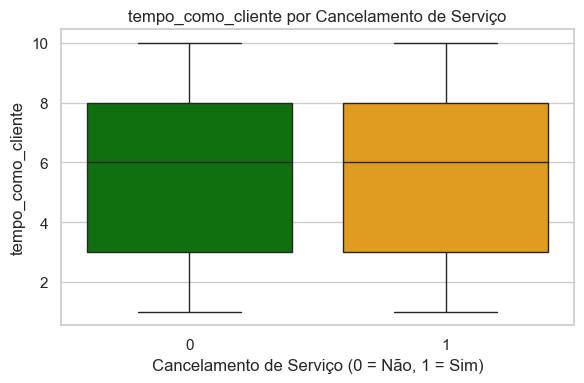

C:\Users\pedro\AppData\Local\Temp\ipykernel_27936\3865104026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Correlação de tempo_como_cliente com cancelamento: 0.0242


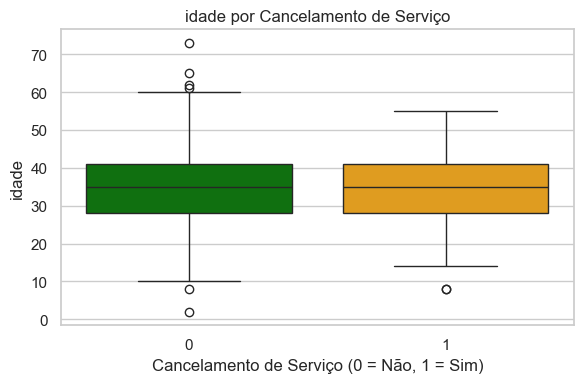

Correlação de idade com cancelamento: -0.0112


C:\Users\pedro\AppData\Local\Temp\ipykernel_27936\3865104026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


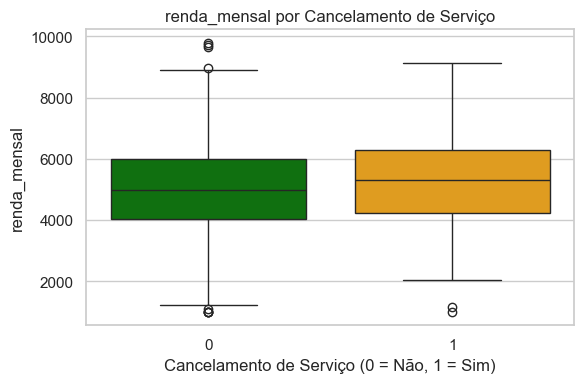

Correlação de renda_mensal com cancelamento: 0.0598


In [83]:
variaveis = ["tempo_como_cliente", "idade", "renda_mensal"]

for var in variaveis:
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x="cancelou_servico",
        y=var,
        data=df,
        palette={"0": "green", "1": "orange"}
    )
    
    plt.title(f"{var} por Cancelamento de Serviço")
    plt.xlabel("Cancelamento de Serviço (0 = Não, 1 = Sim)")
    plt.ylabel(var)
    
    plt.tight_layout()
    plt.show()


    print(f"Correlação de {var} com cancelamento: {df[var].corr(df['cancelou_servico']):.4f}")

>**Notas:** Inicialmente verifiquei a correlação entre o tempo como cliente e notei um resultado muito baixo, o que indicava que essa variável, isoladamente, não era suficiente para explicar o comportamento de cancelamento. Então, decidi verificar a correlação com mais variáveis e percebi que, assim como o tempo como cliente, nenhuma das outras variáveis (idade e renda mensal), de forma isolada, apresenta correlação relevante com o cancelamento. Os gráficos boxplots confirmam essa leitura visualmente, as distribuições de quem cancelou e quem não cancelou são praticamente idênticas. Retomando a hipótese levantada na seção 1.2, a correlação de 0.0598 entre renda mensal e cancelamento confirma que a hipótese não se sustenta, a renda mensal, isoladamente, não explica o comportamento de cancelamento.

>**Notas:** Sobre o gráfico de dispersão, nesse cenário em específico, ele não seria o gráfico ideal pois ele é utilizado em análises entre duas variáveis numéricas, e no exemplo estamos lidando com uma numérica (tempo_como_cliente) e uma categórica (cancelou_servico), portanto o gráfico boxplot acaba sendo a escolha mais apropriada.

---
# 2. Programação com python

### 2.1 Escreva uma função que receba uma série e retorne a versão normalizada pelo robust scaling.

In [84]:
# Função Python para Robust Scaling
def robust_scaling(serie: pd.Series) -> pd.Series:

    # Cálculo da mediana e do IQR
    mediana = serie.median()
    iqr = serie.quantile(0.75) - serie.quantile(0.25)
    # Verificação de IQR zero para evitar divisão por zero
    if iqr == 0:
        raise ValueError("IQR igual a zero: série sem variação suficiente.")
    
    return (serie - mediana) / iqr


# Aplicando função.

var_robust = ["renda_mensal", "tempo_como_cliente", "idade"]

for var in var_robust:
    coluna_nova = f"{var}_scaled"
    
    print(f"--- {var} ---")
    print(f"Original:    {df[var].head().round(2).values}")
    
    df[coluna_nova] = robust_scaling(df[var])
    
    print(f"Normalizado: {df[coluna_nova].head().round(4).values}")
    print()
    print(f"Mediana após normalização: {df[coluna_nova].median():.4f}")
    print()
    print(f"IQR após normalização: {df[coluna_nova].quantile(0.75) - df[coluna_nova].quantile(0.25):.4f}")
    print()

--- renda_mensal ---
Original:    [4452.02 5277.02 2979.31 3542.58 6800.62]
Normalizado: [-0.2927  0.1286 -1.0447 -0.7571  0.9066]

Mediana após normalização: 0.0000

IQR após normalização: 1.0000

--- tempo_como_cliente ---
Original:    [10  2  9  3  2]
Normalizado: [ 0.8 -0.8  0.6 -0.6 -0.8]

Mediana após normalização: 0.0000

IQR após normalização: 1.0000

--- idade ---
Original:    [39 33 41 50 32]
Normalizado: [ 0.3077 -0.1538  0.4615  1.1538 -0.2308]

Mediana após normalização: 0.0000

IQR após normalização: 1.0000



>**Notas:** O exercício pede o uso do RobustScaler, logo, o utilizamos já de primeira. No entanto, em casos onde a base não apresenta tantos outliers podemos utilizar o **StandardScaler** que utiliza da média e desvio padrão para padronizar os dados, para que eles tenham 0 como média e 1 como desvio padrão. Enquanto o RobustScaler, utiliza a mediana e IQR(Q3-Q1) para padronizar os dados, sendo mais resistente a outliers. Nesse caso, ele é uma ótima pedida, visto que identifiquei idades suspeitas na seção 1.2

### 2.2 Simulação de distribuição binomial

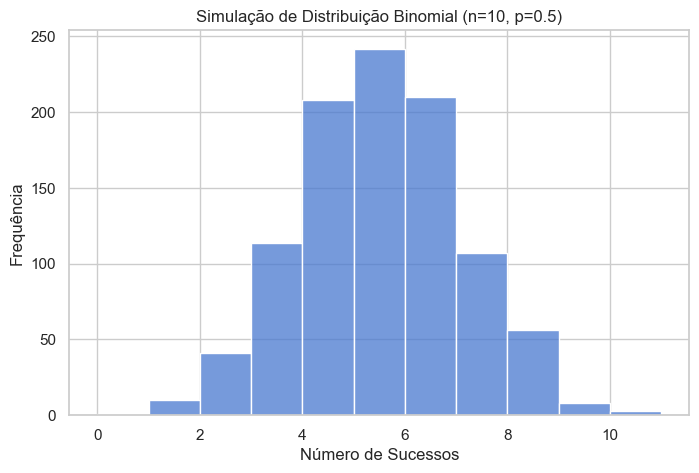

In [85]:
# parâmetros
n = 10
p = 0.5
amostras = 1000

# simulação
dados = np.random.binomial(n=n, p=p, size=amostras)

# visualização
plt.figure(figsize=(8,5))
sns.histplot(dados, bins=range(0, n+2), kde=False)

plt.title("Simulação de Distribuição Binomial (n=10, p=0.5)")
plt.xlabel("Número de Sucessos")
plt.ylabel("Frequência")

plt.show()

>**Notas:** A distribuição binomial modela o número de sucessos em **n** tentativas indepententes, cada um com probabilidade **p** de sucesso. No gráfico, com **n=10** e **p=0.5**, pode-se observar que o esperado foi confirmado, uma vez que há simetria em torno da média (5), ocorrendo uma maior concentração no centro e baixa frequência nas extremidades.

---
# 3. Estatística e Probabilidade

### 3.1 Teste de hipótese - diferença de renda entre homens e mulheres

In [86]:
renda_masc = df[df["sexo"] == "Masculino"]["renda_mensal"]
renda_fem = df[df["sexo"] == "Feminino"]["renda_mensal"]

# H0: não há diferença significativa entre as médias
# H1: há diferença significativa

t_stat, p_valor = stats.ttest_ind(renda_masc, renda_fem)

print("=== Teste t de Student ===")
print()
print(f"Média Masculino:  R$ {renda_masc.mean():,.2f}")
print(f"Média Feminino:   R$ {renda_fem.mean():,.2f}")
print(f"Estatística t:    {t_stat:.4f}")
print(f"p-valor:          {p_valor:.4f}")
print()

significativa = 0.05
if p_valor < significativa:
    print(f"Resultado: p={p_valor:.4f} < a={significativa}.  H0 Rejeitado.")
    print("Há diferença significativa entre as rendas.")
else:
    print(f"Resultado: p={p_valor:.4f} >= a={significativa}.  Não rejeitamos H0.")
    print("Não há diferença significativa entre as rendas.")

=== Teste t de Student ===

Média Masculino:  R$ 5,066.88
Média Feminino:   R$ 5,024.76
Estatística t:    0.4524
p-valor:          0.6511

Resultado: p=0.6511 >= a=0.05.  Não rejeitamos H0.
Não há diferença significativa entre as rendas.


>**Notas:** O teste t de Student foi escolhido por ser adequado para comparar médias de dois grupos independentes, neste caso, renda de homens e mulheres. Com p=0.6511, não rejeitamos H0, ou seja, não há evidência estatística de diferença significativa entre as rendas dos dois grupos neste dataset.

### 3.2 Intervalo de confiança de 95% para a média da idade dos clientes.

In [87]:

idades = df["idade"]

media = idades.mean() # Média de idade.
std = idades.std() # Desvio Padrão.
n = len(idades) # Tamanho da amostra.

# Valor correspondente a 95% de confiança para distribuição normal
z = 1.96

margem_erro = z * (std / np.sqrt(n)) # Cálculo da margem de erro para o intervalo de confiança.

limite_inferior = media - margem_erro
limite_superior = media + margem_erro


print("=== Intervalo de Confiança (95%) - Idade ===")
print()
print(f"Tamanho da amostra: {n}")
print(f"Média da idade:     {media:.2f} anos")
print()
print(f"IC 95%: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print()
print("Interpretação: com 95% de confiança, a média real da")
print(f"idade dos clientes está entre {limite_inferior:.1f} e {limite_superior:.1f} anos.")

=== Intervalo de Confiança (95%) - Idade ===

Tamanho da amostra: 1000
Média da idade:     34.67 anos

IC 95%: [34.07, 35.28]

Interpretação: com 95% de confiança, a média real da
idade dos clientes está entre 34.1 e 35.3 anos.


>**Notas:** Com 95% de confiança, a média real da idade dos clientes está entre 34.1 e 35.3 anos. O intervalo de confiança de 95% comumente é utilizado pois, se a amostragem fosse repetida várias vezes, em 95% dos intervalos calculados, conteria a média real da população.

---
# 4. Machine Learning Supervisionado

### 4.1 Modele a variável `cancelou_servico` usando um modelo de classificação à sua escolha. Separe os dados em treino e teste.

In [88]:
# Preparação das features
df_ml = df.copy()
df_ml["sexo_enc"] = LabelEncoder().fit_transform(df_ml["sexo"])

features = ["idade", "sexo_enc", "renda_mensal", "tempo_como_cliente", "uso_app_diario"]
X = df_ml[features]
y = df_ml["cancelou_servico"]

# Split estratificado — preserva proporção da classe minoritária
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste:  {X_test.shape[0]} registros")
print()
print("Distribuição da variável alvo (cancelou_servico):")
print(y.value_counts(normalize=True).round(3))
print()
print("Nota: dataset desbalanceado (~80% não cancelou). Porntanto, usarei class_weight=balanced.")

Treino: 800 registros
Teste:  200 registros

Distribuição da variável alvo (cancelou_servico):
cancelou_servico
0    0.795
1    0.205
Name: proportion, dtype: float64

Nota: dataset desbalanceado (~80% não cancelou). Porntanto, usarei class_weight=balanced.


>**Notas:** Optei em escolher trabalhar com o modelo **Random Forest** pois ele acaba se destacando perante os demais em algumas particularidades presentes no dataset:

> - Base com tamanho adequado para uso do modelo sem prejuízo de performance.
> - É um bom modelo para trabalhar com variáveis em escalas diferentes (renda em milhares, idade em dezenas).
> - Resiste bem a outliers (vimos que o dataset apresenta).
> - A interpretação não era requisito do teste, portanto, optei pela performance preditiva.
> - Dataset apresenta desbalanceamento de classes.


#### Aplicando **class_weight = balanced** no modelo

In [89]:
# Criar o modelo
modelo = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

# Treinar
modelo.fit(X_train, y_train)

# Prever
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

>**Notas:** Usei o **class_weight = balanced** para lidar com o desbalanceamento da variável. Esse ajuste faz com que o modelo atribua um peso maior a classe menor (cancelamento), evitando viés para a classe maior, melhorando a capacidade de identificação dos casos de interesse.

### 4.2 Avalie o modelo usando métricas como F1, accuracy e ROC-AUC.

In [90]:
print("=== Métricas de Avaliação ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()


=== Métricas de Avaliação ===
Accuracy:  0.7900
F1-Score:  0.0455
ROC-AUC:   0.5001



>**Notas:** De acordo com essas métricas, o modelo não possuiu uma performance satisfatória. A acurácia de 79%, mesmo que razoável, acaba sendo enganosa dado o desbalanceamento. Isso fica nítido pelo F1-score (0.045), que deixa explícito que o modelo não consegue identificar cancelamentos, ou seja, ela falha exatamente no que importa. Já o ROC-AUC de 50% indica que o modelo não consegue separar bem as classes. Essas métricas só evidenciam o que já tinha visto nos gráficos e correlações próximas a zero analisadas no EDA, mostrando que as variáveis do dataset não possuem poder preditivo para explicar o cancelamento. 

### 4.3 Realize tuning simples com GridSearchCV.

In [91]:
from sklearn.model_selection import GridSearchCV

# Quais combinações de configurações testar
param_grid = {
    "n_estimators": [50, 100],   # número de árvores
    "max_depth": [5, 10, None],  # profundidade máxima de cada árvore
    "class_weight": ["balanced"] # mantém o balanceamento
}

# Cria o GridSearch
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,           # divide os dados em 5 partes para validação
    scoring="f1",   # otimiza pelo F1, não pela accuracy
    n_jobs=-1      
)

# Treina testando todas as combinações
gs.fit(X_train, y_train)

print(f"Melhores hiperparâmetros: {gs.best_params_}")
print(f"Melhor F1 (validação cruzada): {gs.best_score_:.4f}")
print()

# Avalia o melhor modelo no conjunto de teste
melhor_modelo = gs.best_estimator_
y_pred_gs = melhor_modelo.predict(X_test)
y_prob_gs = melhor_modelo.predict_proba(X_test)[:, 1]

print("=== Métricas após Tuning ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gs):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_gs):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_gs):.4f}")

Melhores hiperparâmetros: {'class_weight': 'balanced', 'max_depth': 5, 'n_estimators': 50}
Melhor F1 (validação cruzada): 0.1793

=== Métricas após Tuning ===
Accuracy:  0.6850
F1-Score:  0.2410
ROC-AUC:   0.4792


>**Notas:** Após o tuning, o F1-Score saiu de 0.045 para 0.241 - uma melhora relevante, mas ainda insatisfatória. O ROC-AUC de 0.479 continua próximo de 0.50, confirmando que o modelo ainda não consegue separar as classes de forma útil. O GridSearchCV encontrou a melhor combinação de hiperparâmetros testada, mas o problema central persiste: as features disponíveis não possuem poder preditivo suficiente. No caso deste dataset, acredito que nenhum tuning será suficiente para resolver um problema de dados.

---
# 5. Machine Learning Não Supervisionado

### 5.1 Aplique PCA ao dataset padronizado e visualize os dois primeiros componentes principais.

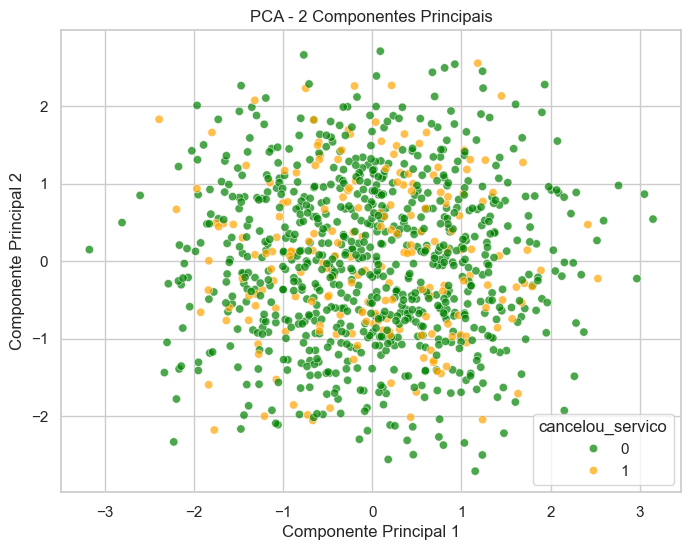

Valor do PC1: 0.2151
Valor do PC2: 0.2137
Total: 0.4289


In [92]:
# -------------------------
# 1. Preparar dados
# -------------------------
features_pca = ["idade", "sexo", "renda_mensal", "tempo_como_cliente", "uso_app_diario"]
X = df[features_pca]
y = df["cancelou_servico"]

# One-hot encoding (se tiver categórica)
X = pd.get_dummies(X, drop_first=True)

# -------------------------
# 2. Padronizar
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 3. PCA (2 componentes)
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------------------------
# 4. Criar DataFrame para plot
# -------------------------
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cancelou_servico"] = y.values

# -------------------------
# 5. Visualização
# -------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cancelou_servico",
    palette={0: "green", 1: "orange"},
    alpha=0.7
)

plt.title("PCA - 2 Componentes Principais")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

print(f"Valor do PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Valor do PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total: {sum(pca.explained_variance_ratio_):.4f}")

>**Notas:** O uso do PCA é para reduzirmos a dimensionalidade dos nossos dados. Ele comprime as variáveis originais em componentes que tentam preservar o máximo de variação dos dados. No caso, ele vai combinar as variáveis, PC1 captura a combinação com maior variação dos dados, enquanto PC2 a segunda maior. 

> O valor de PC1 foi de 21.51%, enquanto PC2 21.37%, totalizando 42.89%. Esse resultado, abaixo de 70%, indica que muitas informações foram perdidas durante a redução, o que também acaba explicando a mistura das classes no gráfico plotado acima.

### 5.2 Faça uma clusterização (KMeans ou DBSCAN) e interprete os grupos. 

c:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

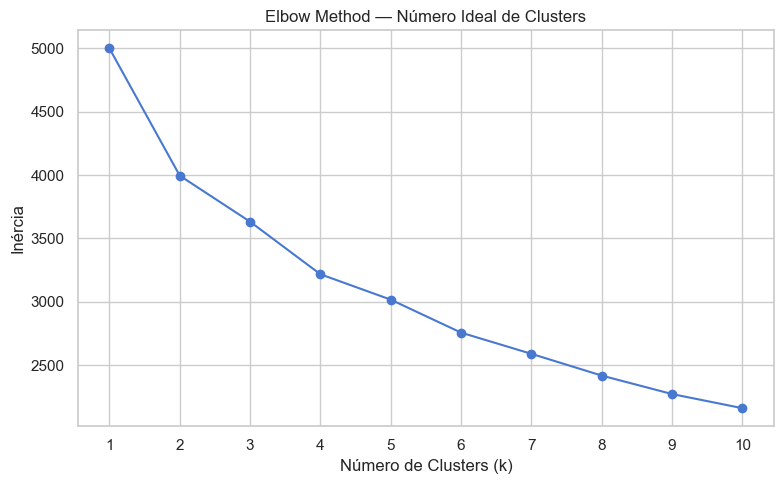

In [93]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.title("Elbow Method — Número Ideal de Clusters")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inércia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

c:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


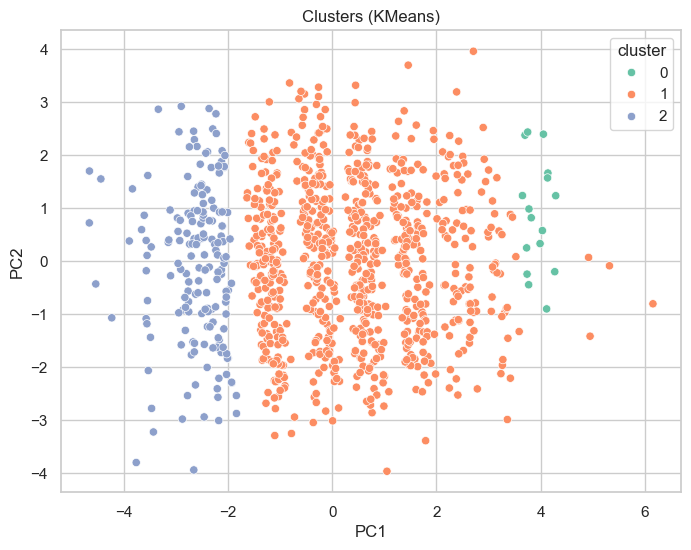

In [94]:
# -------------------------
# 1. Preparar dados
# -------------------------
X = df.drop("cancelou_servico", axis=1)
X = pd.get_dummies(X, drop_first=True)

# -------------------------
# 2. Padronizar
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 3. KMeans
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# -------------------------
# 4. Adicionar ao DataFrame
# -------------------------
df["cluster"] = clusters

# -------------------------
# 5. Visualizar com PCA (opcional)
# -------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("Clusters (KMeans)")
plt.show()


In [95]:
df.groupby("cluster")[["idade", "renda_mensal", "tempo_como_cliente", "uso_app_diario"]].mean().round(2)

,idade,renda_mensal,tempo_como_cliente,uso_app_diario
cluster,,,,
0,57.56,5302.14,5.81,49.17
1,37.25,5015.18,5.54,44.54
2,20.40,5169.34,5.52,46.17


---
# 6. Storytelling com Dados

### Conclusão para liderança não técnica

**O que os dados nos dizem:**

Analisei o comportamento de 1.000 clientes do aplicativo de bem-estar. Atualmente, **20,5% dos clientes cancelam o serviço** - aproximadamente 1 em cada 5 usuários. Investiguei todas as variáveis disponíveis - idade, renda, sexo, tempo como cliente e uso diário do app, e nenhuma delas, isoladamente, explica o comportamento de cancelamento. O modelo preditivo construído confirmou essa limitação, com performance equivalente a um chute aleatório. Isso não significa que o problema não tem solução, significa que os dados atuais não são suficientes para resolvê-lo. Os clientes foram segmentados em três perfis distintos principalmente por faixa etária, mas com taxas de cancelamento e padrões de uso semelhantes entre si, reforçando que o cancelamento é influenciado por fatores comportamentais que ainda não estamos medindo.

**2 ações práticas recomendadas (1 bônus):**

1. **Enriquecer a coleta de dados:** incluir variáveis comportamentais como frequência de login, funcionalidades mais usadas, histórico de suporte. Com dados comportamentais mais granulares, um modelo preditivo conseguirá identificar clientes em risco antes do cancelamento acontecer.

2. **Ativar campanhas de retenção segmentadas por cluster:** clientes jovens (Cluster 2) e maduros (Cluster 0) têm contextos de vida diferentes e provavelmente motivações distintas para cancelar. Comunicações, ofertas e abordagens personalizadas por faixa etária tendem a ser mais eficazes do que campanhas massivas.

3. **Investigar o perfil dos menores de idade na base** Identifiquei 35 clientes com idade abaixo de 18 anos, incluindo um registro com 2 anos. Isso pode indicar erro de preenchimento ou uma regra de negócio não documentada. Se forem registros incorretos, estão distorcendo todas as análises. Entender e corrigir esse problema junto à área responsável é uma ação simples com impacto direto na qualidade de qualquer decisão tomada com esses dados.

---
## 7. [Opcional] Mini Case Final — Redução de Churn no App de Bem-estar

### Plano de Abordagem Analítica

**Entendimento do problema:** o objetivo é reduzir o cancelamento do serviço. Isso é um problema de **classificação binária** (cancelou/não cancelou) com impacto direto em receita recorrente.

**Etapas da abordagem:**
1. EDA para entender o perfil dos clientes e identificar padrões
2. Teste de hipóteses para validar diferenças entre grupos
3. Modelagem preditiva para identificar clientes em risco
4. Clusterização para segmentar a base e personalizar ações
5. Tradução dos resultados em recomendações de negócio

In [96]:
# Consolidando as principais descobertas analíticas

print("===== RESUMO ANALÍTICO — CHURN DO APP DE BEM-ESTAR =====")
print()
print(f"Total de clientes analisados: {len(df)}")
print(f"Taxa de cancelamento: {df['cancelou_servico'].mean():.1%}")
print()

print("--- Perfil geral ---")
print(f"Idade média: {df['idade'].mean():.1f} anos (IC 95%: 34.1 a 35.3)")
print(f"Renda mediana: R$ {df['renda_mensal'].median():,.0f}")
print(f"Uso médio diário do app: {df['uso_app_diario'].mean():.1f} min")
print()

print("--- Diferenças por sexo ---")
print(f"Renda mediana Feminino:  R$ {df[df['sexo']=='Feminino']['renda_mensal'].median():,.0f}")
print(f"Renda mediana Masculino: R$ {df[df['sexo']=='Masculino']['renda_mensal'].median():,.0f}")
print("Teste t de renda por sexo: p=0.6511 → sem diferença significativa")
print()

print("--- Modelo preditivo ---")
print("Algoritmo: Random Forest com balanceamento de classes")
print("Variável mais importante: uso_app_diario e renda_mensal")
print()
print("--- Conclusão ---")
print("O dataset atual não permite alta precisão preditiva (ROC-AUC ~0.5),")
print("indicando que variáveis comportamentais mais granulares são essenciais")
print("para um modelo de churn eficaz.")
print()
print("Recomendações:")
print("1. Enriquecer dados com frequência de login, NPS e histórico de suporte")
print("2. Implementar campanhas de retenção segmentadas por cluster")
print("3. Monitorar o modelo em produção e retreiná-lo com novos dados mensalmente")
print("4. Investigar o perfil dos menores de idade na base para entender o motivo do cadastro e comportamento desses clientes.")

===== RESUMO ANALÍTICO — CHURN DO APP DE BEM-ESTAR =====

Total de clientes analisados: 1000
Taxa de cancelamento: 20.5%

--- Perfil geral ---
Idade média: 34.7 anos (IC 95%: 34.1 a 35.3)
Renda mediana: R$ 5,025
Uso médio diário do app: 44.9 min

--- Diferenças por sexo ---
Renda mediana Feminino:  R$ 5,036
Renda mediana Masculino: R$ 4,999
Teste t de renda por sexo: p=0.6511 → sem diferença significativa

--- Modelo preditivo ---
Algoritmo: Random Forest com balanceamento de classes
Variável mais importante: uso_app_diario e renda_mensal

--- Conclusão ---
O dataset atual não permite alta precisão preditiva (ROC-AUC ~0.5),
indicando que variáveis comportamentais mais granulares são essenciais
para um modelo de churn eficaz.

Recomendações:
1. Enriquecer dados com frequência de login, NPS e histórico de suporte
2. Implementar campanhas de retenção segmentadas por cluster
3. Monitorar o modelo em produção e retreiná-lo com novos dados mensalmente
4. Investigar o perfil dos menores de id